<a href="https://colab.research.google.com/github/EmanuelleAndrade/Agendei/blob/emanuelleandrade41%40gmail.com/desafio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 303ms/step - accuracy: 0.7925 - loss: 0.5931 - val_accuracy: 0.8421 - val_loss: 0.4964
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8262 - loss: 0.5138 - val_accuracy: 0.8947 - val_loss: 0.4082
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8716 - loss: 0.4353 - val_accuracy: 0.9474 - val_loss: 0.3300
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8643 - loss: 0.4095 - val_accuracy: 1.0000 - val_loss: 0.2795
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8609 - loss: 0.3597 - val_accuracy: 0.9474 - val_loss: 0.2463
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8828 - loss: 0.3449 - val_accuracy: 1.0000 - val_loss: 0.2162
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8649 - loss: 0.3286 - val_accuracy: 1.0000 - val_loss: 0.1953
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8647 - loss: 0.3000 - val_accuracy: 1.0000 - val_loss

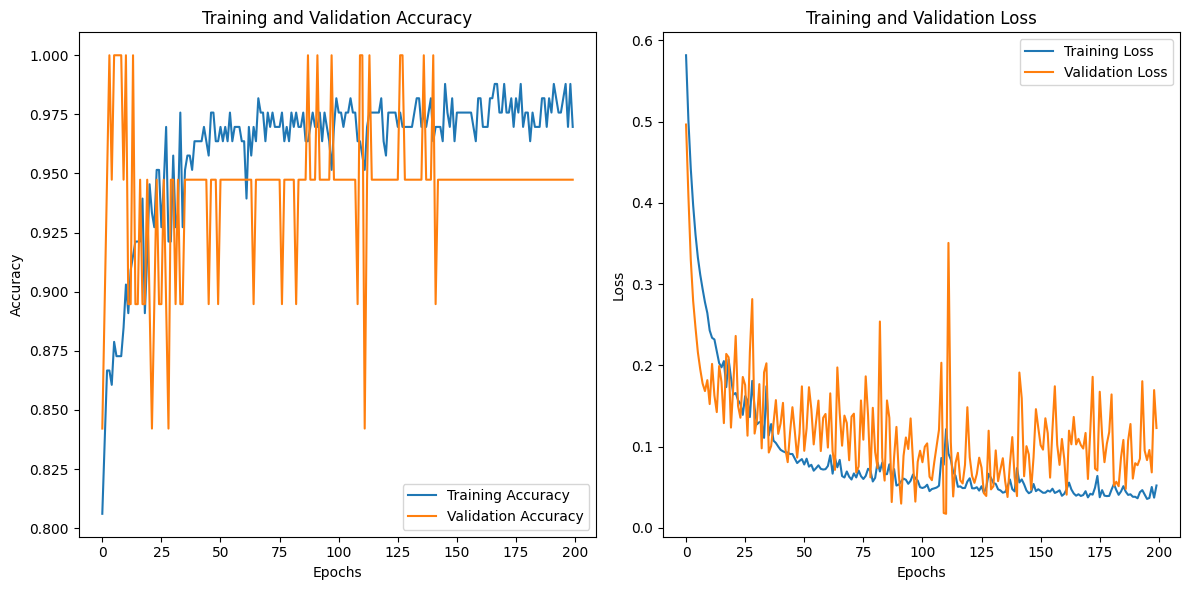

In [1]:
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Carregar o conjunto de dados
df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/imports-85.csv')

# Processar os dados
df_enum = pd.get_dummies(df).drop('normalized-losses', axis=1).fillna(0)

# Definindo um valor de limiar para classificação (por exemplo, preço médio)
limite_preco = df_enum['price'].median()  # ou use a média, dependendo do seu critério
df_enum['price_class'] = (df_enum['price'] > limite_preco).astype(int)  # 1 se acima do limite, 0 se abaixo

# Separar características e alvo
dados = df_enum.drop(columns=['price', 'price_class'])
alvo = df_enum['price_class']

# Normalizar os dados
scaler = MinMaxScaler(feature_range=(-1, 1))
dados = scaler.fit_transform(dados)

# Dividir o conjunto de dados em treino e teste
x_train, x_test, y_train, y_test = train_test_split(dados, alvo, test_size=0.10, random_state=42)

# Criar o modelo de classificação
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Camada de saída com ativação sigmoide para classificação binária
])

# Compilar o modelo
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='binary_crossentropy',  # Usar perda de entropia cruzada para classificação
              metrics=['accuracy'])

# Treinar o modelo e capturar o histórico
history = model.fit(x_train, y_train, epochs=200, validation_split=0.1)

# Avaliar o modelo
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Acurácia: {accuracy:.2f}')

# Previsões
y_pred_train = model.predict(x_train).round()
y_pred_test = model.predict(x_test).round()

# Visualizar resultados
plt.figure(figsize=(12, 6))

# Gráfico de precisão de treinamento
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Gráfico de perda
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()